In [1]:
# Dotted paper — three densities (regular / extra / super).
# Per-density DOT_SIZE preserves a constant dot-to-spacing ratio of 8%
# across densities (cell-area fill ≈ 0.5%). Super at DOT_SIZE=10,
# SPACING=125 is the visual baseline; extra and regular are scaled up
# so sparse dots stay visible.
# CENTER_MARGIN = 125 px stays constant, so dot CENTERS sit on the exact
# same lattice for all three densities. Only edge-margin varies:
#   regular: DOT_SIZE=20 → edge_margin=115
#   extra:   DOT_SIZE=12 → edge_margin=119
#   super:   DOT_SIZE=10 → edge_margin=120
# See common.py for the geometry model; SPEC.md has the full numbers.
# Output: ../output/dotted/{dotted,extra-dotted,super-dotted}.png
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, make_dot_template,
    grid_counts, lattice_x, lattice_y,
    output_path, variant_name, DENSITIES,
)

MODE = "dotted"

# ratio = DOT_SIZE / SPACING = 10/125 = 8%   (super is the reference)
DOT_SIZES = {
    "regular": 20,   # 20/250 = 0.080
    "extra":   12,   # 12/150 = 0.080
    "super":   10,   # 10/125 = 0.080
}

In [2]:
def render_dotted(spacing, dot_size):
    """Stamp dots of the given size on the canonical lattice."""
    dot = make_dot_template(size=dot_size)
    img = blank_page()
    n_x, n_y = grid_counts(spacing)
    for i in range(n_x):
        x = lattice_x(i, spacing, dot_size)
        for j in range(n_y):
            img.paste(dot, (x, lattice_y(j, spacing, dot_size)))
    draw_header(img)
    return img, n_x, n_y

regular  spacing=250  dot=20  34×43= 1462 dots  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/dotted/dotted.png


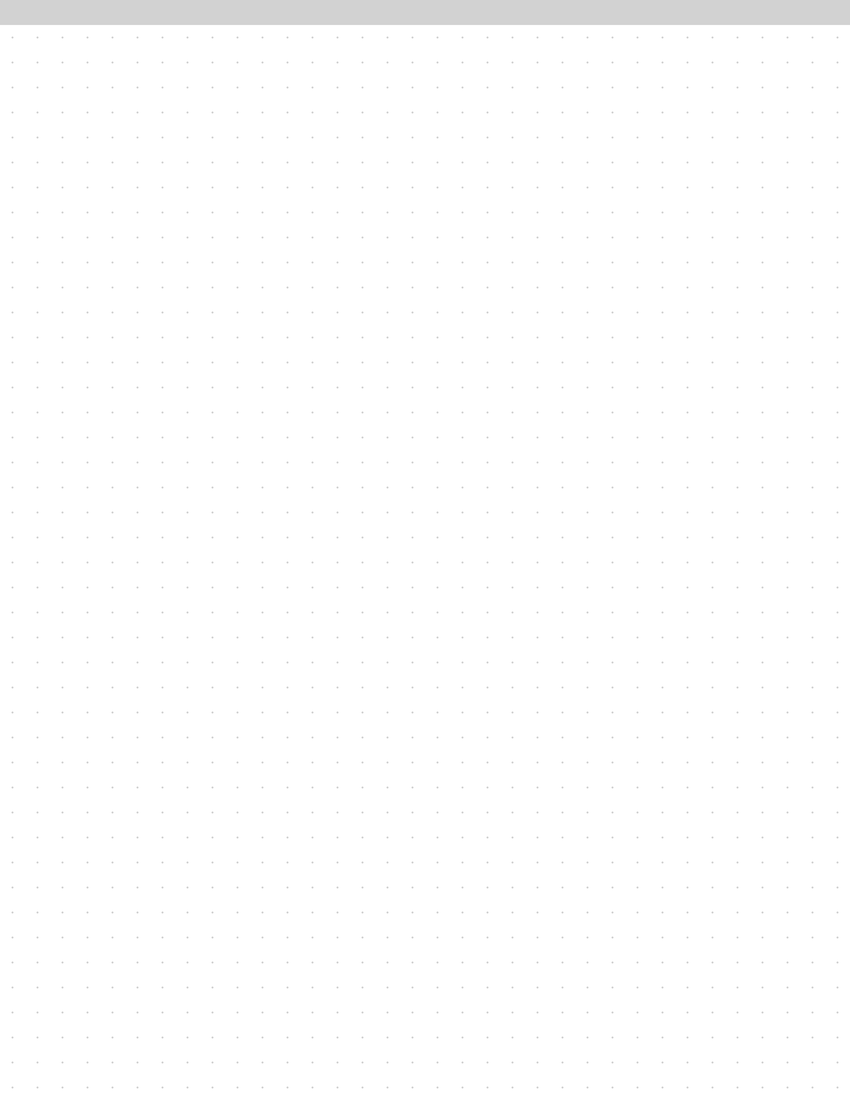

extra    spacing=150  dot=12  56×71= 3976 dots  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/dotted/extra-dotted.png


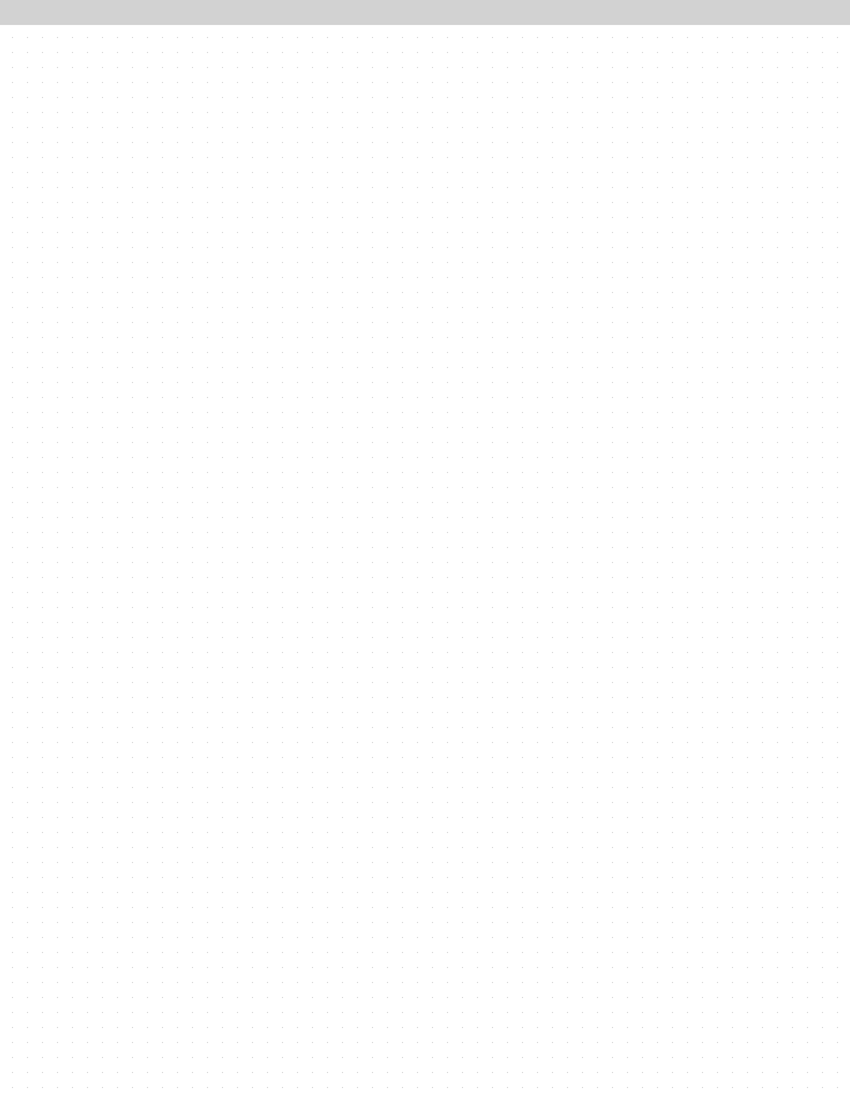

super    spacing=125  dot=10  67×85= 5695 dots  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/dotted/super-dotted.png


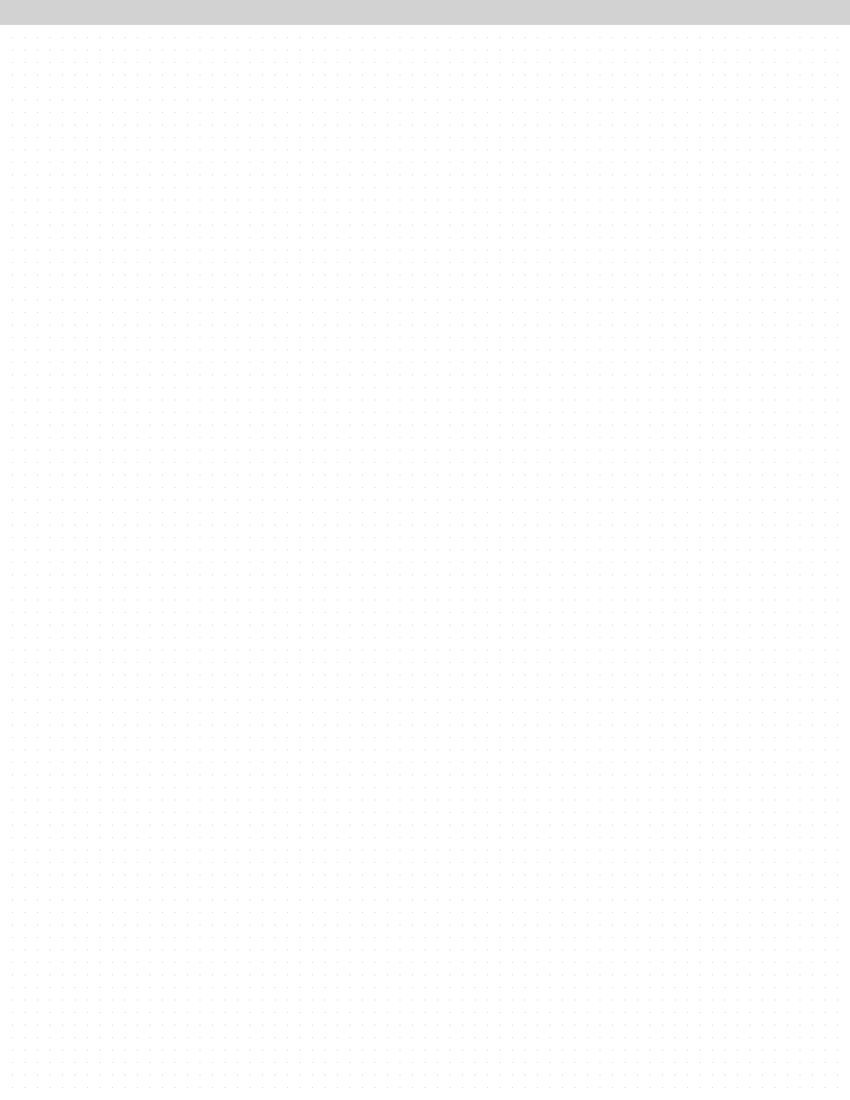

In [3]:
for density, spacing in DENSITIES.items():
    dot_size = DOT_SIZES[density]
    img, n_x, n_y = render_dotted(spacing, dot_size)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} spacing={spacing:3d}  dot={dot_size:2d}  "
        f"{n_x}×{n_y}={n_x*n_y:5d} dots  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))